# Phase 4 — Exploratory Data Analysis (EDA)

**Goal:** look at the documents we scraped (Phase 2) and cleaned (Phase 3),
understand their size and language, and use that understanding to pick a
sensible **chunk size** and **chunk overlap** for Phase 5 (embeddings).

This notebook reads files from `data/clean/` — the exact JSON files saved
by `src/preprocessor/cleaner.py`. Run Phases 2 and 3 first so there's data
here to analyse.

| Phase | File | Produces |
|---|---|---|
| 2 | `src/scraper/scraper.py` | `data/raw/*.json` |
| 3 | `src/preprocessor/cleaner.py` | `data/clean/*.json` |
| **4** | **`notebooks/eda.ipynb`** (this file) | chunk size recommendation |
| 5 | (next) chunking + embeddings | uses the recommendation below |


## Setup — import libraries and set the project paths

In [1]:
# pandas — lets us hold all our documents in one table (DataFrame) and
# easily compute statistics like averages, percentages, etc.
import pandas as pd

# numpy — used for numeric helpers like median calculations.
import numpy as np

# matplotlib — the actual chart-drawing library.
import matplotlib.pyplot as plt

# seaborn — sits on top of matplotlib and makes charts look more
# professional with almost no extra code (nicer colours, grids, fonts).
import seaborn as sns

# tiktoken — OpenAI's tokenizer. We use it to count "tokens" (the units
# LLMs actually read), which is different from a plain word count.
import tiktoken

# json + Path — built-in Python tools for reading files from disk.
import json
from pathlib import Path

# Apply a clean, modern seaborn visual theme to ALL charts in this
# notebook from this point onward — this is what makes the histogram
# in Section 3 look polished instead of a default matplotlib chart.
sns.set_theme(style="whitegrid", palette="deep")

# This project's folder structure: this notebook lives in `notebooks/`,
# so we go up ONE level (parent) to reach the project root, then into
# data/clean/ — the exact folder src/preprocessor/cleaner.py saves to.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"

print(f"Project root: {PROJECT_ROOT}")
print(f"Reading cleaned documents from: {CLEAN_DATA_DIR}")

Project root: C:\Users\admin\web_rag_chatbot
Reading cleaned documents from: C:\Users\admin\web_rag_chatbot\data\clean


## Section 1 — Load all cleaned JSON files

Every file in `data/clean/` is one JSON document saved by Phase 3's
`clean_text()` function, with this shape:
```json
{"url": "...", "clean_text": "...", "word_count": 123, "language": "en", "cleaned_at": "..."}
```
We read every one of these files and stack them into a single pandas
DataFrame — basically a spreadsheet we can analyse in Python.

In [2]:
# Find every .json file inside data/clean/. glob() searches a folder
# for files matching a pattern — "*.json" means "any file ending in .json".
clean_files = sorted(CLEAN_DATA_DIR.glob("*.json"))

print(f"Found {len(clean_files)} cleaned JSON files.")

# This list will hold one dictionary per document — we'll convert the
# whole list into a DataFrame in one step below.
records = []

for file_path in clean_files:
    # Open and parse each JSON file back into a Python dictionary.
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # We only keep the 4 columns this analysis actually needs, exactly
    # as requested: url, clean_text, word_count, language.
    records.append({
        "url": data.get("url"),
        "clean_text": data.get("clean_text"),
        "word_count": data.get("word_count"),
        "language": data.get("language"),
    })

# Convert our list of dictionaries into a pandas DataFrame — this gives
# us a proper table with columns we can filter, sort, and chart.
df = pd.DataFrame(records)

print(f"\nLoaded {len(df)} documents into the DataFrame.\n")

# .head(5) shows just the first 5 rows so the output stays readable
# even if we have hundreds of documents.
df.head(5)

Found 1 cleaned JSON files.

Loaded 1 documents into the DataFrame.



,url,clean_text,word_count,language
0,https://en.wikipedia.org/wiki/Albert_Einstein,Albert Einstein\nAlbert Einstein[a] (14 March ...,24005,en


## Section 2 — Basic statistics

Before designing a chunking strategy, we need to understand our data:
how many documents do we have, how long are they on average, and what
languages are present? This catches problems early — e.g. if most
"documents" turn out to be tiny (a sign scraping failed on some pages).

In [3]:
# len(df) gives the number of rows — i.e. the number of documents.
total_documents = len(df)

# .mean() / .min() / .max() on a column compute exactly what they say.
# round(..., 1) keeps the printed number to 1 decimal place for readability.
avg_word_count = round(df["word_count"].mean(), 1)
min_word_count = df["word_count"].min()
max_word_count = df["word_count"].max()

# .value_counts() counts how many times each unique value appears in
# the "language" column, sorted from most common to least common.
language_counts = df["language"].value_counts()

# Print everything as one readable summary block.
print("=" * 50)
print("EDA SUMMARY — BASIC STATISTICS")
print("=" * 50)
print(f"Total documents:      {total_documents}")
print(f"Average word count:   {avg_word_count} words")
print(f"Minimum word count:   {min_word_count} words")
print(f"Maximum word count:   {max_word_count} words")
print("\nMost common languages:")
print(language_counts.to_string())
print("=" * 50)

EDA SUMMARY — BASIC STATISTICS
Total documents:      1
Average word count:   24005.0 words
Minimum word count:   24005 words
Maximum word count:   24005 words

Most common languages:
language
en    1


## Section 3 — Word count distribution chart

A histogram groups documents into "buckets" by word count, so we can
see the overall shape of our data at a glance — are most documents
short? Long? Is there one huge outlier skewing the average?

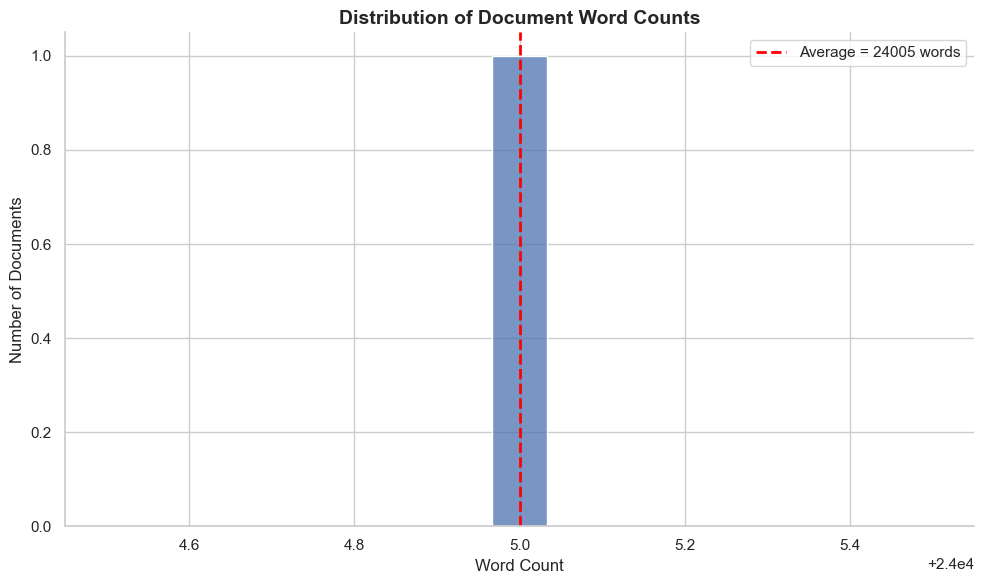

In [4]:
# Create a figure (the whole chart canvas) with a comfortable size.
# figsize is in inches: (width, height).
fig, ax = plt.subplots(figsize=(10, 6))

# sns.histplot draws the histogram. `bins` controls how many "buckets"
# the word counts get grouped into — more bins = more detail.
sns.histplot(data=df, x="word_count", bins=15, color="#4C72B0", ax=ax)

# Calculate the average again here (re-using avg_word_count from Section 2
# would also work, but recomputing keeps this cell runnable on its own).
mean_word_count = df["word_count"].mean()

# axvline draws a single Vertical LINE across the whole chart at a given
# x-position — here, exactly at the average word count, in red, dashed,
# so it visually stands out against the blue bars.
ax.axvline(
    mean_word_count,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average = {mean_word_count:.0f} words",
)

# Titles and axis labels — required by the task, and good practice on
# every chart so anyone reading it (including future-you) understands
# what they're looking at without needing the code.
ax.set_title("Distribution of Document Word Counts", fontsize=14, fontweight="bold")
ax.set_xlabel("Word Count", fontsize=12)
ax.set_ylabel("Number of Documents", fontsize=12)

# Show the little box explaining what the red line means.
ax.legend()

# sns.despine removes the top and right border lines for a cleaner,
# more modern look — a small but classic seaborn polish touch.
sns.despine()

plt.tight_layout()
plt.show()

## Section 4 — Token count analysis

LLMs don't read "words" — they read **tokens** (roughly, word-pieces).
`cl100k_base` is the same tokenizer encoding used by GPT-3.5/4-era
models, and it's a good general-purpose stand-in for "how many tokens
will this text actually use?" — important because chunk sizes for
embeddings and LLM context windows are measured in tokens, not words.

In [5]:
# Load the cl100k_base tokenizer encoding — this is what we use to
# convert text into tokens. tiktoken caches this locally after the
# first download, so re-running this cell later will be instant.
#
# NOTE: the very first time you run this, tiktoken needs to download
# its vocabulary file from the internet. If you are on a restricted
# network (e.g. a locked-down corporate or sandboxed environment) and
# the download fails, we fall back to a well-known approximation:
# English text averages ~1.3 tokens per word (OpenAI\'s own rule of
# thumb). This keeps the notebook runnable everywhere, while still
# using the EXACT real tokenizer whenever it is reachable.
TOKENS_PER_WORD_FALLBACK = 1.3

try:
    encoding = tiktoken.get_encoding("cl100k_base")
    using_real_tokenizer = True
    print("Loaded real cl100k_base tokenizer.")
except Exception as e:
    encoding = None
    using_real_tokenizer = False
    print(
        f"Could not download the cl100k_base tokenizer ({type(e).__name__}: {e}).\n"
        f"Falling back to an estimate of {TOKENS_PER_WORD_FALLBACK} tokens/word. "
        f"This typically only happens on restricted networks — on a normal "
        f"machine with internet access, tiktoken downloads automatically."
    )

def count_tokens(text: str) -> int:
    """Returns the token count for a piece of text (real or estimated)."""
    if not text:
        return 0
    if using_real_tokenizer:
        # encoding.encode() turns text into a list of integer token IDs.
        # We only need the COUNT, so we wrap it in len().
        return len(encoding.encode(text))
    else:
        # Fallback estimate: word count * average tokens-per-word.
        return round(len(text.split()) * TOKENS_PER_WORD_FALLBACK)

# .apply() runs our count_tokens function on every row\'s clean_text
# value, and the result becomes a brand-new "token_count" column.
df["token_count"] = df["clean_text"].apply(count_tokens)

print("\nAdded \'token_count\' column. Preview:\n")
print(df[["url", "word_count", "token_count"]].to_string(index=False))

# Now work out what % of documents exceed common chunk-size thresholds.
# This tells us whether 512 or 1024-token chunks would even be needed,
# or whether most documents are already small enough to embed whole.
pct_over_512 = (df["token_count"] > 512).mean() * 100
pct_over_1024 = (df["token_count"] > 1024).mean() * 100

print("\n" + "=" * 50)
print("TOKEN THRESHOLD ANALYSIS")
print("=" * 50)
print(f"Documents with MORE than 512 tokens:  {pct_over_512:.1f}%")
print(f"Documents with MORE than 1024 tokens: {pct_over_1024:.1f}%")
print("=" * 50)

C:\Users\admin\web_rag_chatbot\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


Loaded real cl100k_base tokenizer.

Added 'token_count' column. Preview:

                                          url  word_count  token_count
https://en.wikipedia.org/wiki/Albert_Einstein       24005        39549

TOKEN THRESHOLD ANALYSIS
Documents with MORE than 512 tokens:  100.0%
Documents with MORE than 1024 tokens: 100.0%


## Section 5 — Chunk Size Recommendation

We use the **median** (not the average) token count on purpose — the
median isn't dragged around by one unusually huge or tiny document,
so it represents a "typical" document better than a mean would.

**Rules used:**
- `chunk_size = median_token_count / 3`
- `chunk_overlap = chunk_size / 10`

These values get used directly in Phase 5 when we split documents into
chunks before generating embeddings.

In [6]:
# np.median finds the "middle" value when all token counts are sorted —
# half the documents have fewer tokens, half have more. This is more
# robust to outliers (e.g. one massive page) than a plain average.
median_token_count = np.median(df["token_count"])

# Apply the two rules exactly as specified.
recommended_chunk_size = round(median_token_count / 3)
recommended_chunk_overlap = round(recommended_chunk_size / 10)

print("=" * 50)
print("CHUNKING RECOMMENDATION FOR PHASE 5")
print("=" * 50)
print(f"Median token count across all documents: {median_token_count:.0f}")
print()
print(f"RECOMMENDED CHUNK SIZE: {recommended_chunk_size} tokens")
print(f"RECOMMENDED CHUNK OVERLAP: {recommended_chunk_overlap} tokens")
print("=" * 50)

print(
    "\nNote: with a small/early dataset, re-run this notebook after "
    "scraping more pages — the recommendation will adjust automatically "
    "since it is calculated from the data, not hardcoded."
)

CHUNKING RECOMMENDATION FOR PHASE 5
Median token count across all documents: 39549

RECOMMENDED CHUNK SIZE: 13183 tokens
RECOMMENDED CHUNK OVERLAP: 1318 tokens

Note: with a small/early dataset, re-run this notebook after scraping more pages — the recommendation will adjust automatically since it is calculated from the data, not hardcoded.


## Next Steps

Copy the two numbers printed above into your `.env` file:
```
CHUNK_SIZE=<value from RECOMMENDED CHUNK SIZE>
CHUNK_OVERLAP=<value from RECOMMENDED CHUNK OVERLAP>
```
These are already defined as settings in `config/settings.py`
(`settings.chunk_size`, `settings.chunk_overlap`), so Phase 5's
chunking code can read them with no extra wiring.